## 1. Setup & Data Loading <a id='1'></a>

In [6]:
# ── Install any missing packages ──────────────────────────────────────────────
import subprocess, sys
pkgs = ['scikit-learn','xgboost','lightgbm','statsmodels','folium','scipy','plotly','seaborn']
for p in pkgs:
    subprocess.run([sys.executable,'-m','pip','install',p,'--quiet'],check=False)

In [7]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [8]:
# ── Configure the appearance of plots in Python, mainly with Matplotlib and Seaborn ─────────────────────────────────────────────
plt.rcParams.update({'figure.figsize':(12,5),'axes.grid':True,'grid.alpha':0.3})
sns.set_theme(style='whitegrid') #white background, light gray grid lines
print('Libraries loaded.')

Libraries loaded.


#### Data loading

In [9]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('dublinbikes_history_clean.csv', parse_dates=['last_reported'])#last_reported column into a datetime type automatically
df.sort_values(['station_id','last_reported'], inplace=True)
df.head()

,station_id,name,num_bikes_available,num_docks_available,is_renting,is_returning,last_reported,capacity,lat,lon
0,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:05:00,31,53.340927,-6.262501
1,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:15:00,31,53.340927,-6.262501
2,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:25:00,31,53.340927,-6.262501
3,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:35:00,31,53.340927,-6.262501
4,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:45:00,31,53.340927,-6.262501


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
df.reset_index(drop=True, inplace=True)
df.head()

,station_id,name,num_bikes_available,num_docks_available,is_renting,is_returning,last_reported,capacity,lat,lon
0,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:05:00,31,53.340927,-6.262501
1,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:15:00,31,53.340927,-6.262501
2,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:25:00,31,53.340927,-6.262501
3,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:35:00,31,53.340927,-6.262501
4,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:45:00,31,53.340927,-6.262501


In [12]:
print(f'Shape : {df.shape}')

Shape : (7416360, 10)


## 2. Feature Engineering <a id='2'></a>

In [13]:
# Derived columns used everywhere
df['utilisation'] = df['num_bikes_available'] / df['capacity'].replace(0, np.nan) #utilisation (bikes/capacity)

In [14]:
# replace(0, np.nan) is used to avoid division by zero. avoid 5 / 0

What fraction of the station's capacity is currently filled with bikes.

1.0 = station is completely full of bikes (no free docks)

0.0 = station is completely empty

0.5 = half the docks have bikes

In [15]:
df['pct_full']    = df['num_docks_available'] / df['capacity'].replace(0, np.nan) #(docks/capacity)

What fraction of the station's capacity is free docks.

1.0 = all docks are empty (no bikes at all)

0.0 = all docks are occupied

In [16]:
print(f'Shape : {df.shape}')

Shape : (7416360, 12)


In [17]:
print(f'Period: {df["last_reported"].min()}  →  {df["last_reported"].max()}')

Period: 2024-08-01 00:05:00  →  2025-08-31 23:55:00


In [18]:
print(f'Stations: {df["station_id"].nunique()}')

Stations: 115


In [19]:
df.head(3)

,station_id,name,num_bikes_available,num_docks_available,is_renting,is_returning,last_reported,capacity,lat,lon,utilisation,pct_full
0,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:05:00,31,53.340927,-6.262501,0.193548,0.806452
1,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:15:00,31,53.340927,-6.262501,0.193548,0.806452
2,1,CLARENDON ROW,6,25,True,True,2024-08-01 00:25:00,31,53.340927,-6.262501,0.193548,0.806452


Split datatime

In [20]:
import pandas as pd
df['last_reported'] = pd.to_datetime(df['last_reported'], format='mixed')
df['hour']        = df['last_reported'].dt.hour
df['minute']      = df['last_reported'].dt.minute
df['dayofweek']   = df['last_reported'].dt.dayofweek        # 0=Mon
df['is_weekend']  = (df['dayofweek'] >= 5).astype(int)
df['month']       = df['last_reported'].dt.month
df['quarter']     = df['last_reported'].dt.quarter
df['dayofyear']   = df['last_reported'].dt.dayofyear
df['week']        = df['last_reported'].dt.isocalendar().week.astype('Int64')

In [21]:
# Time-of-day segments
def time_segment(h):
    if  7 <= h < 10: return 'morning_rush'
    if 10 <= h < 16: return 'midday'
    if 16 <= h < 20: return 'evening_rush'
    if 20 <= h < 24: return 'evening'
    return 'night'

df['time_segment'] = df['hour'].apply(time_segment)

In [22]:
# Irish public holidays (2024) — binary flag
irish_holidays_2024 = pd.to_datetime([
    '2024-01-01','2024-02-05','2024-03-17','2024-03-29','2024-04-01',
    '2024-05-06','2024-06-03','2024-08-05','2024-10-28','2024-12-25','2024-12-26'
])
df['is_holiday'] = df['last_reported'].dt.normalize().isin(irish_holidays_2024).astype(int)

In [23]:
# Season
df['season'] = pd.cut(df['month'], bins=[0,2,5,8,11,12],
                      labels=['Winter','Spring','Summer','Autumn','Winter2']).astype(str) #pd.cut() requires unique labels.
df['season'] = df['season'].replace('Winter2','Winter')

In [24]:
#0–2 Winter, 2–5 Spring, 5–8 Summer, 8–11 Autumn, 11–12 Winter2

In [25]:
#Jan (1) Feb (2) → Winter, Mar-May → Spring, Jun-Aug → Summer,Sep-Nov → Autumn, Dec (12) → Winter2

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7416360 entries, 0 to 7416359
Data columns (total 23 columns):
 #   Column               Dtype         
---  ------               -----         
 0   station_id           int64         
 1   name                 object        
 2   num_bikes_available  int64         
 3   num_docks_available  int64         
 4   is_renting           bool          
 5   is_returning         bool          
 6   last_reported        datetime64[ns]
 7   capacity             int64         
 8   lat                  float64       
 9   lon                  float64       
 10  utilisation          float64       
 11  pct_full             float64       
 12  hour                 int32         
 13  minute               int32         
 14  dayofweek            int32         
 15  is_weekend           int64         
 16  month                int32         
 17  quarter              int32         
 18  dayofyear            int32         
 19  week                 

In [27]:
#Everything is fully visible and aligned
print(df[['hour','dayofweek','is_weekend','month','season','is_holiday','time_segment']].head(3).to_string())

   hour  dayofweek  is_weekend  month  season  is_holiday time_segment
0     0          3           0      8  Summer           0        night
1     0          3           0      8  Summer           0        night
2     0          3           0      8  Summer           0        night


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7416360 entries, 0 to 7416359
Data columns (total 23 columns):
 #   Column               Dtype         
---  ------               -----         
 0   station_id           int64         
 1   name                 object        
 2   num_bikes_available  int64         
 3   num_docks_available  int64         
 4   is_renting           bool          
 5   is_returning         bool          
 6   last_reported        datetime64[ns]
 7   capacity             int64         
 8   lat                  float64       
 9   lon                  float64       
 10  utilisation          float64       
 11  pct_full             float64       
 12  hour                 int32         
 13  minute               int32         
 14  dayofweek            int32         
 15  is_weekend           int64         
 16  month                int32         
 17  quarter              int32         
 18  dayofyear            int32         
 19  week                 

## 3. Predictive / Forecasting <a id='3'></a>

### 3a. Short-term Demand Forecasting (15 / 30 / 60 min)

In [29]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

##### Work on a single busy station for demonstration

In [30]:
STATION = df['station_id'].value_counts().index[0]
s = df[df['station_id'] == STATION].copy().sort_values('last_reported').reset_index(drop=True)

In [31]:
STATION

np.int64(69)

In [32]:
s

,station_id,name,num_bikes_available,num_docks_available,is_renting,is_returning,last_reported,capacity,lat,lon,...,minute,dayofweek,is_weekend,month,quarter,dayofyear,week,time_segment,is_holiday,season
0,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:10:00,40,53.342636,-6.238695,...,10,3,0,8,3,214,31,night,0,Summer
1,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:20:00,40,53.342636,-6.238695,...,20,3,0,8,3,214,31,night,0,Summer
2,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:30:00,40,53.342636,-6.238695,...,30,3,0,8,3,214,31,night,0,Summer
3,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:40:00,40,53.342636,-6.238695,...,40,3,0,8,3,214,31,night,0,Summer
4,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:50:00,40,53.342636,-6.238695,...,50,3,0,8,3,214,31,night,0,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79466,69,GRAND CANAL DOCK,13,27,True,True,2025-08-31 23:10:00,40,53.342636,-6.238695,...,10,6,1,8,3,243,35,evening,0,Summer
79467,69,GRAND CANAL DOCK,13,27,True,True,2025-08-31 23:20:00,40,53.342636,-6.238695,...,20,6,1,8,3,243,35,evening,0,Summer
79468,69,GRAND CANAL DOCK,14,26,True,True,2025-08-31 23:30:00,40,53.342636,-6.238695,...,30,6,1,8,3,243,35,evening,0,Summer
79469,69,GRAND CANAL DOCK,14,26,True,True,2025-08-31 23:40:00,40,53.342636,-6.238695,...,40,6,1,8,3,243,35,evening,0,Summer


In [33]:
# Lag features (each row = 10-min snapshot)
for lag in [1, 3, 6, 12, 24, 36, 48]:       # lags in number of rows (~10-min each)
    s[f'lag_{lag}'] = s['num_bikes_available'].shift(lag)

Since each row is a ~10-minute snapshot, the lags represent

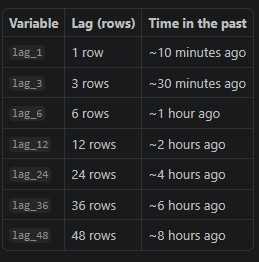

In [34]:
from IPython.display import Image
Image(filename='lag.jpg', width = 200, height = 100)

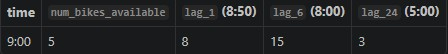

In [35]:
Image(filename='exm.jpg', width = 400, height = 200)

The model sees 5 bikes now, but 15 an hour ago — that trend is a strong signal for the short-term forecast target.

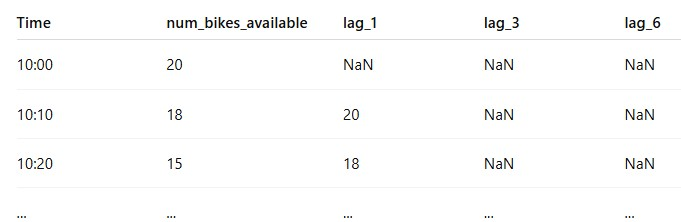

In [36]:
Image(filename='nan.jpg', width = 400, height = 200)

The XGBoost model learns rules like:

"When num_bikes_available is low AND lag_6 was much higher predict even lower availability soon"
That falling trend (15 → 5 over an hour) is much more predictive than just knowing the current count.



In time series forecasting this is the core idea behind lag features

In [37]:
s

,station_id,name,num_bikes_available,num_docks_available,is_renting,is_returning,last_reported,capacity,lat,lon,...,time_segment,is_holiday,season,lag_1,lag_3,lag_6,lag_12,lag_24,lag_36,lag_48
0,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:10:00,40,53.342636,-6.238695,...,night,0,Summer,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:20:00,40,53.342636,-6.238695,...,night,0,Summer,9.0,NaN,NaN,NaN,NaN,NaN,NaN
2,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:30:00,40,53.342636,-6.238695,...,night,0,Summer,9.0,NaN,NaN,NaN,NaN,NaN,NaN
3,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:40:00,40,53.342636,-6.238695,...,night,0,Summer,9.0,9.0,NaN,NaN,NaN,NaN,NaN
4,69,GRAND CANAL DOCK,9,31,True,True,2024-08-01 00:50:00,40,53.342636,-6.238695,...,night,0,Summer,9.0,9.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79466,69,GRAND CANAL DOCK,13,27,True,True,2025-08-31 23:10:00,40,53.342636,-6.238695,...,evening,0,Summer,12.0,12.0,13.0,17.0,13.0,13.0,18.0
79467,69,GRAND CANAL DOCK,13,27,True,True,2025-08-31 23:20:00,40,53.342636,-6.238695,...,evening,0,Summer,13.0,11.0,13.0,16.0,13.0,13.0,16.0
79468,69,GRAND CANAL DOCK,14,26,True,True,2025-08-31 23:30:00,40,53.342636,-6.238695,...,evening,0,Summer,13.0,12.0,13.0,15.0,12.0,12.0,16.0
79469,69,GRAND CANAL DOCK,14,26,True,True,2025-08-31 23:40:00,40,53.342636,-6.238695,...,evening,0,Summer,14.0,13.0,12.0,14.0,13.0,14.0,15.0


In [38]:
# Rolling statistics
s['roll_mean_6']  = s['num_bikes_available'].shift(1).rolling(6).mean()
s['roll_std_6']   = s['num_bikes_available'].shift(1).rolling(6).std()
s['roll_mean_24'] = s['num_bikes_available'].shift(1).rolling(24).mean()

Low std → station is steady, easy to predict

High std → station is fluctuating rapidly, harder to predict

In [39]:
# Targets: +10 min ≈ +1 row, +30 min ≈ +3 rows, +60 min ≈ +6 rows
s['target_10']  = s['num_bikes_available'].shift(-1)
s['target_30']  = s['num_bikes_available'].shift(-3)
s['target_60']  = s['num_bikes_available'].shift(-6)

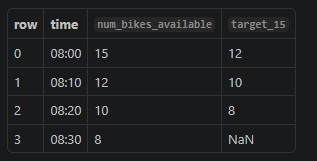

In [40]:
Image(filename='lead.jpg', width = 300, height = 100)

In [41]:
s.dropna(inplace=True)

In [42]:
FEAT_COLS = [c for c in s.columns if c.startswith('lag_') or c.startswith('roll_')
             or c in ['hour','minute','dayofweek','is_weekend','month','is_holiday']]

In [43]:
results = {}
for horizon, target_col in [('10min','target_10'),('30min','target_30'),('60min','target_60')]:
    X = s[FEAT_COLS]
    y = s[target_col]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                              random_state=42, verbosity=0)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    results[horizon] = {'MAE': round(mae,3), 'RMSE': round(rmse,3), 'R²': round(r2,3),
                        'model': model, 'X_te': X_te, 'y_te': y_te, 'y_pred': y_pred}
    print(f'Horizon {horizon:>6s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')

Horizon  10min  MAE=1.440  RMSE=2.201  R²=0.967
Horizon  30min  MAE=2.084  RMSE=3.123  R²=0.934
Horizon  60min  MAE=2.726  RMSE=3.966  R²=0.893


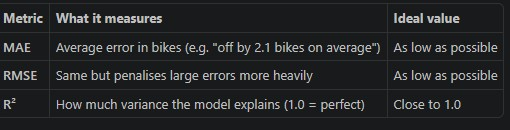

In [44]:
 Image(filename='result.jpg', width = 400, height = 200)

What you'd expect to see

Accuracy typically degrades as the horizon increases:

10min → best MAE and R² (easier to predict near future)

30min → slightly worse

60min → worst (more uncertainty the further ahead you predict)

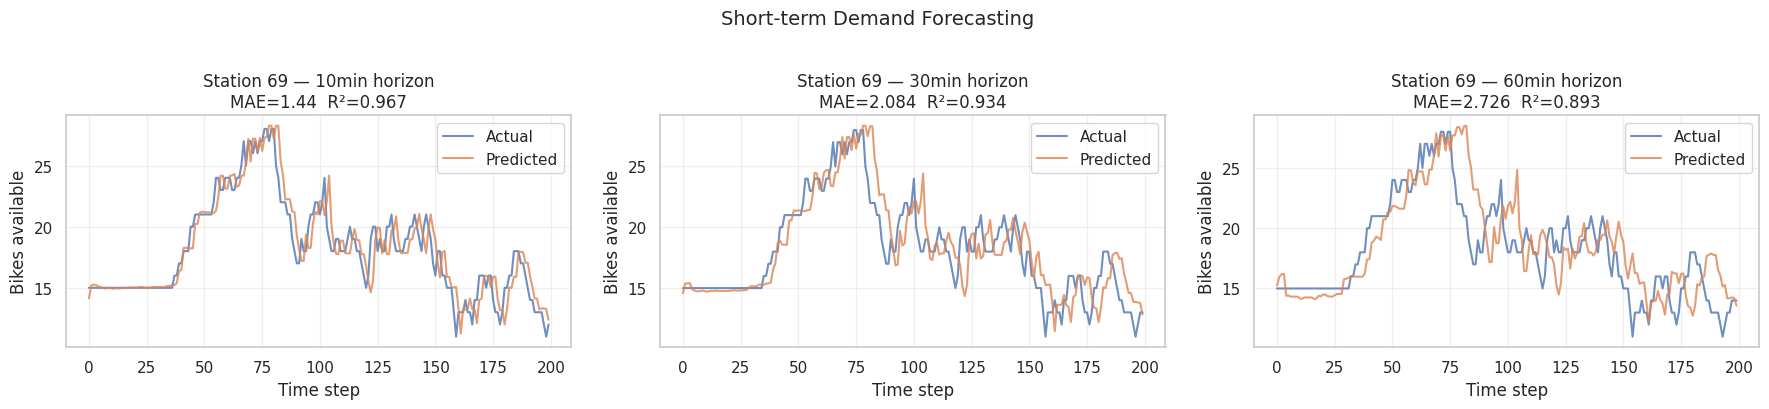

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (horizon, res) in zip(axes, results.items()):
    ax.plot(res['y_te'].values[-200:], label='Actual', alpha=0.8)
    ax.plot(res['y_pred'][-200:],      label='Predicted', alpha=0.8)
    ax.set_title(f'Station {STATION} — {horizon} horizon\nMAE={res["MAE"]}  R²={res["R²"]}')
    ax.set_xlabel('Time step'); ax.set_ylabel('Bikes available')
    ax.legend()
plt.suptitle('Short-term Demand Forecasting', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

### 3b. Peak-hour Demand Prediction

In [46]:
# Average availability by hour and station, then rank busyness
peak = (df.groupby(['station_id','name','hour'])['num_bikes_available']
          .mean().reset_index(name='avg_bikes'))#It calculates the average number of bikes available at each station, broken down by hour of the day.

In [47]:
#For example, all rows for Station 42, at 8am (across every day in the dataset) form one group.
#For each group, calculate the average bikes available.
#So "Station 42 at 8am" might average 3.2 bikes across all the Monday–Sunday 8am readings in the data.

In [48]:
peak #Each station gets 24 rows (one per hour), showing its typical availability pattern throughout the day.

,station_id,name,hour,avg_bikes
0,1,CLARENDON ROW,0,9.121471
1,1,CLARENDON ROW,1,8.857014
2,1,CLARENDON ROW,2,8.816926
3,1,CLARENDON ROW,3,8.928818
4,1,CLARENDON ROW,4,9.097678
...,...,...,...,...
2755,117,HANOVER QUAY EAST,19,5.657665
2756,117,HANOVER QUAY EAST,20,5.759041
2757,117,HANOVER QUAY EAST,21,5.637463
2758,117,HANOVER QUAY EAST,22,5.474848


In [49]:
# Busyness = low bike availability during rush hours
rush_hours = [7, 8, 9, 16, 17, 18, 19]
rush = peak[peak['hour'].isin(rush_hours)]
busiest = (rush.groupby(['station_id','name'])['avg_bikes']
               .mean().reset_index(name='rush_avg_bikes')
               .sort_values('rush_avg_bikes'))

print('Top 10 Busiest Stations During Rush Hours (fewest available bikes):')
print(busiest.head(10).to_string(index=False))

Top 10 Busiest Stations During Rush Hours (fewest available bikes):
 station_id                    name  rush_avg_bikes
         51        YORK STREET WEST        1.120594
         15        HARDWICKE STREET        1.823885
         59    DENMARK STREET GREAT        2.511351
         61         HARDWICKE PLACE        2.715384
         30    PARNELL SQUARE NORTH        2.755270
        111    MOUNTJOY SQUARE EAST        3.198474
          2      BLESSINGTON STREET        3.331255
         12           ECCLES STREET        3.332476
         79      ECCLES STREET EAST        3.473414
         89 FITZWILLIAM SQUARE EAST        4.182443


### 3c. Long-term Trends & Seasonality

In [50]:
# System-wide daily average availability
#Computes the system-wide daily average bike availability and smooths it with moving averages to reveal long-term trends.
daily = (df.groupby(df['last_reported'].dt.date)['num_bikes_available']
           .mean().reset_index()) #df['last_reported'].dt.date strips the time, keeping only the date (e.g. 2024-03-17)
daily.columns = ['date','avg_bikes'] #Groups all stations, all snapshots from that day together
daily['date'] = pd.to_datetime(daily['date']) #.mean() gives one single number per day — the average bikes available across the entire system that day
daily['7d_ma']  = daily['avg_bikes'].rolling(7).mean()
daily['30d_ma'] = daily['avg_bikes'].rolling(30).mean()

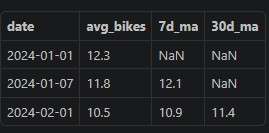

In [51]:
 Image(filename='date.jpg', width = 300, height = 100)

The first 6 rows have NaN for 7d_ma (not enough past days yet), and the first 29 rows have NaN for 30d_ma.

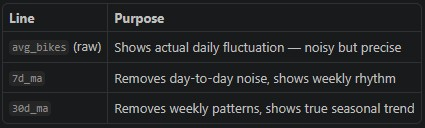

In [52]:
Image(filename='date_ex.jpg', width = 350, height = 150)

Together they let you see both short-term volatility and long-term direction on the same chart.

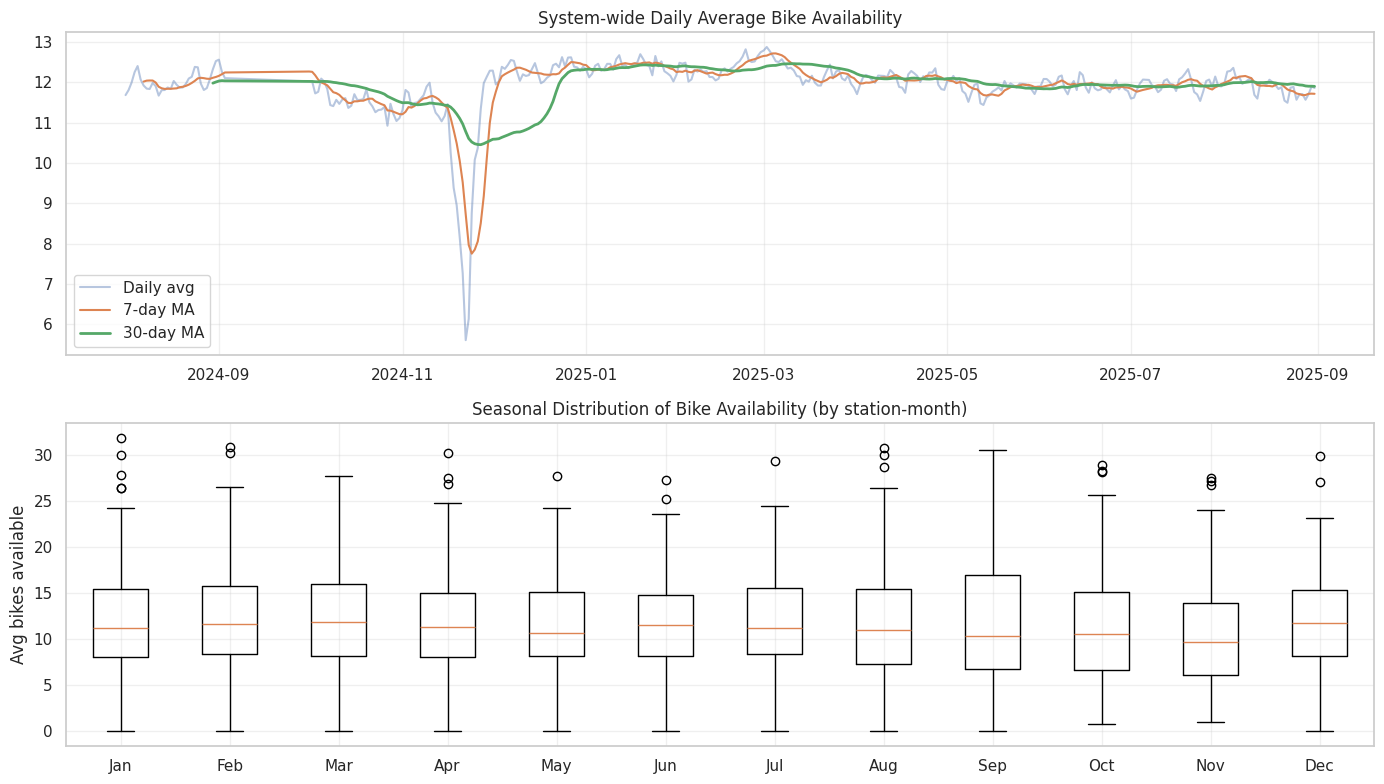

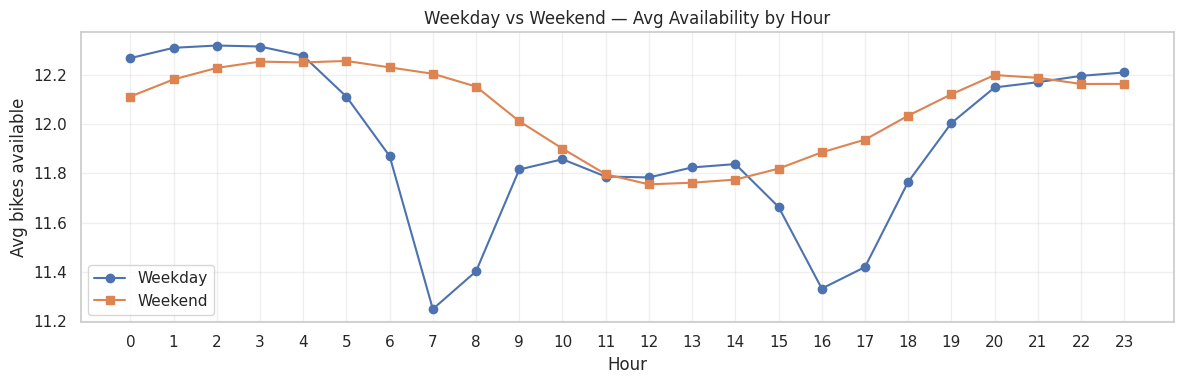

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily trend
axes[0].plot(daily['date'], daily['avg_bikes'], alpha=0.4, label='Daily avg')
axes[0].plot(daily['date'], daily['7d_ma'],  label='7-day MA')
axes[0].plot(daily['date'], daily['30d_ma'], label='30-day MA', linewidth=2)
axes[0].set_title('System-wide Daily Average Bike Availability'); axes[0].legend()

# Seasonal box plots Each month’s boxplot shows:
# median, spread, variability, outliers
monthly = (df.groupby([df['last_reported'].dt.to_period('M'), 'station_id'])['num_bikes_available']
             .mean().reset_index())
monthly.columns = ['month','station_id','avg_bikes']
monthly['month_str'] = monthly['month'].astype(str)
axes[1].boxplot([monthly[monthly['month_str'].str.endswith(m)]['avg_bikes'].dropna()
                 for m in ['01','02','03','04','05','06','07','08','09','10','11','12']],
                labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].set_title('Seasonal Distribution of Bike Availability (by station-month)')
axes[1].set_ylabel('Avg bikes available')

plt.tight_layout(); plt.show()

# Weekday vs Weekend
wk = df.groupby(['is_weekend','hour'])['num_bikes_available'].mean().unstack('hour')
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(range(24), wk.loc[0], marker='o', label='Weekday')
ax.plot(range(24), wk.loc[1], marker='s', label='Weekend')
ax.set_xticks(range(24)); ax.set_xlabel('Hour'); ax.set_ylabel('Avg bikes available')
ax.set_title('Weekday vs Weekend — Avg Availability by Hour'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Classification <a id='4'></a>

### 4a. Station Full / Empty Risk Prediction (Binary Classification)

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)
import lightgbm as lgb

In [55]:
# Defines what "at risk" means. 2 is used rather than 0
#because waiting until a station is completely empty/full is too late to act.


EMPTY_THRESH = 2   #will this station be near-empty (<=2 bikes) within ~30 min?
FULL_THRESH  = 2   # <=2 docks free → near-full

cls_df = df.copy()
cls_df = cls_df.sort_values(['station_id','last_reported'])
cls_df['future_bikes'] = cls_df.groupby('station_id')['num_bikes_available'].shift(-3)
cls_df['risk_empty']   = (cls_df['future_bikes'] <= EMPTY_THRESH).astype(int)
cls_df['risk_full']    = (cls_df.groupby('station_id')['num_docks_available'].shift(-3) <= FULL_THRESH).astype(int)
cls_df.dropna(subset=['future_bikes'], inplace=True)

CLS_FEATS = ['num_bikes_available','num_docks_available','utilisation',
             'hour','dayofweek','is_weekend','month','is_holiday','capacity']

for label, target in [('Near-Empty Risk','risk_empty'),('Near-Full Risk','risk_full')]:
    X  = cls_df[CLS_FEATS].fillna(0)
    y  = cls_df[target]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False, stratify=None)
    clf = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                              class_weight='balanced', random_state=42, verbose=-1)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_te, y_prob)
    print(f'\n=== {label} (AUC={auc:.3f}) ===')
    print(classification_report(y_te, y_pred, target_names=['No Risk','At Risk']))


=== Near-Empty Risk (AUC=0.990) ===
              precision    recall  f1-score   support

     No Risk       0.99      0.94      0.97   1129944
     At Risk       0.84      0.97      0.90    353259

    accuracy                           0.95   1483203
   macro avg       0.92      0.96      0.93   1483203
weighted avg       0.95      0.95      0.95   1483203


=== Near-Full Risk (AUC=0.998) ===
              precision    recall  f1-score   support

     No Risk       1.00      0.98      0.99   1388746
     At Risk       0.77      0.98      0.87     94457

    accuracy                           0.98   1483203
   macro avg       0.89      0.98      0.93   1483203
weighted avg       0.98      0.98      0.98   1483203



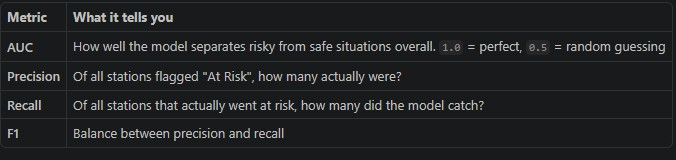

In [56]:
Image(filename='per.jpg', width = 500, height = 300)

The most important number here

Recall = 0.97 for At Risk is what matters most in practice.

It means the model only misses 3% of stations that genuinely run out of bikes.

In a real bike system, a missed warning (false negative) means a user arrives at an empty station that's a bad experience.

A false alarm just means an unnecessary rebalancing truck visit  much less costly.

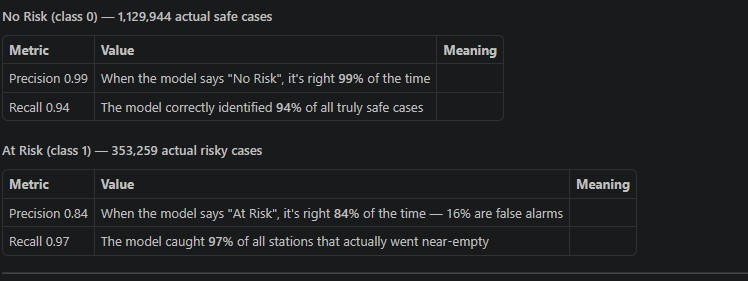

In [57]:
Image(filename='pred1.jpg', width = 500, height = 300)

Overall — AUC = 0.998

Even better than the empty risk model. Nearly perfect discrimination between risky and safe stations.

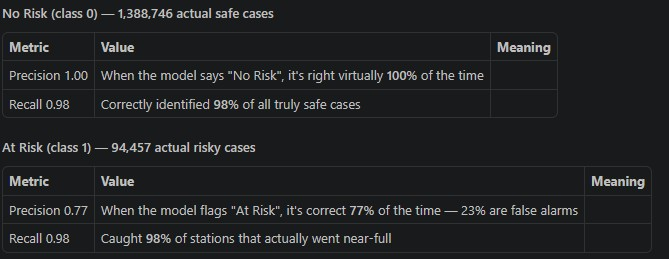

In [58]:
Image(filename='pred2.jpg', width = 400, height = 200)

Key difference vs the Near-Empty model

Compare the support numbers:

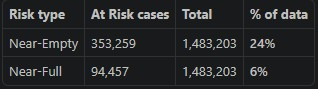

In [59]:
Image(filename='near_empt.jpg', width = 400, height = 200)

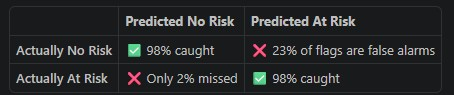

In [60]:
Image(filename='tradeoff.jpg', width = 400, height = 200)

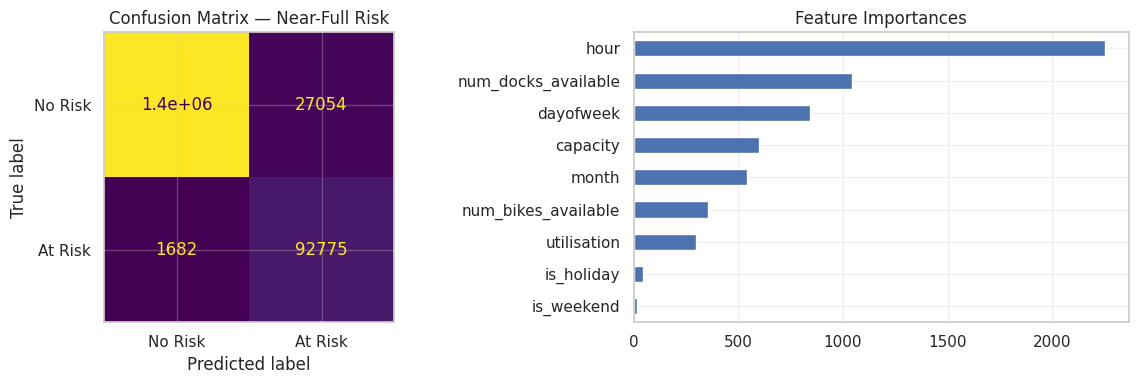

In [61]:
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred,
    display_labels=['No Risk','At Risk'], ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — {label}')
# Feature importance
fi = pd.Series(clf.feature_importances_, index=CLS_FEATS).sort_values(ascending=True)
fi.plot.barh(ax=axes[1])
axes[1].set_title('Feature Importances')
plt.tight_layout(); plt.show()

### 4b. Station Operational Status Classifier (is_renting / is_returning)

In [62]:
# Predict whether a station will stop renting within next snapshot
ops_df = df.copy()
ops_df['future_renting'] = ops_df.groupby('station_id')['is_renting'].shift(-1).astype(float)
ops_df.dropna(subset=['future_renting'], inplace=True)
ops_df['future_renting'] = ops_df['future_renting'].astype(int)

OPS_FEATS = ['num_bikes_available','num_docks_available','utilisation',
             'hour','dayofweek','is_weekend','month','capacity']
X  = ops_df[OPS_FEATS].fillna(0)
y  = ops_df['future_renting']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
auc = roc_auc_score(y_te, rf.predict_proba(X_te)[:,1])
print(f'Operational status prediction  AUC={auc:.3f}')
print(classification_report(y_te, y_pred, target_names=['Not Renting','Renting']))

Operational status prediction  AUC=0.785
              precision    recall  f1-score   support

 Not Renting       0.17      0.38      0.23      1561
     Renting       1.00      1.00      1.00   1481688

    accuracy                           1.00   1483249
   macro avg       0.58      0.69      0.62   1483249
weighted avg       1.00      1.00      1.00   1483249

